Each week, you will apply the concepts of that week to your Integrated Capstone Project’s dataset. In preparation for Milestone One, create a Jupyter Notebook (similar to in Module B, semester two) that illustrates these lessons. There are no specific questions to answer in your Jupyter Notebook files in this course; your general goal is to analyze your data, using the methods you have learned about in this course and in this program, and draw interesting conclusions. 

For Week 1, include concepts such as linear regression with polynomial terms, interaction terms, multicollinearity, variance inflation factor and regression, and categorical and continuous features. Complete your Jupyter Notebook homework by 11:59 pm ET on Sunday. 

In Week 7, you will compile your findings from your Jupyter Notebook homework into your Milestone One assignment for grading. For full instructions and the rubric for Milestone One, refer to the following link. 

sets the proper root directory so helper load function works

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/jamieconner/projects/bu/dx799_01/mod_c_capstone


Load the data using my helper functions to both load and split wisconsin data

In [2]:
from src.load_data import load_wisconsin, load_brazil, split_X_y


df_wisc, target = load_wisconsin()
X, y = split_X_y(df_wisc, target)

X.describe()


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


train test split data for baseline regression model



In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler
import numpy as np 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)


base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

cv_scores = cross_val_score(
    base_pipeline,
    X_train,
    y_train,
    cv=5, 
    scoring= "roc_auc"
)


baseline_mean_train_cv = np.mean(cv_scores)

print(f"baseline model training cv: {baseline_mean_train_cv}")




baseline model training cv: 0.9951496388028895


for simplicity and noise reduction in polynomial intereaction i'm going to subset a few features from the full data set - choosing features that represent size, shape, texture, boundary formatioon 

In [4]:


subset_feat= ["radius1", "symmetry1", "compactness1", "texture1", "concave_points1"]


X_train_subset = X_train[subset_feat]
X_tests_subset = X_test[subset_feat]

b_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

cv_scores = cross_val_score(
    base_pipeline,
    X_train_subset,
    y_train,
    cv=5, 
    scoring= "roc_auc"
)


subset_mean_train_cv = np.mean(cv_scores)

print(f"baseline subset model training cv: {subset_mean_train_cv}")




baseline subset model training cv: 0.9844169246646027


add in polyterms 

In [5]:
from sklearn.preprocessing import PolynomialFeatures


poly_pipeline = Pipeline([
    ("polynomial", PolynomialFeatures((2,3))),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

cv_scores = cross_val_score(
    poly_pipeline,
    X_train_subset,
    y_train,
    cv=5, 
    scoring= "roc_auc"
)


subset_poly_mean_train_cv = np.mean(cv_scores)

print(f"baseline subset poly model training cv: {subset_poly_mean_train_cv}")

baseline subset poly model training cv: 0.9882352941176471


In [6]:
print(f"baseline model training cv: {baseline_mean_train_cv}")

print(f"baseline subset model training cv: {subset_mean_train_cv}")


print(f"baseline subset poly model training cv: {subset_poly_mean_train_cv}")

baseline model training cv: 0.9951496388028895
baseline subset model training cv: 0.9844169246646027
baseline subset poly model training cv: 0.9882352941176471


I"m going to test all three models on the test set. I know in general we supposed to pick on final model to use on test, but i'm not going to change my models after the fact, just one final comparison to see how the models generalize. 

In [7]:
from sklearn.metrics import accuracy_score, roc_auc_score

# full-feature baseline
base_pipeline.fit(X_train, y_train)

y_pred = base_pipeline.predict(X_test)
y_prob = base_pipeline.predict_proba(X_test)[:, 1]

base_test_accuracy = accuracy_score(y_test, y_pred)
base_test_roc_auc = roc_auc_score(y_test, y_prob)

print(f"Full baseline test accuracy: {base_test_accuracy:.4f}")
print(f"Full baseline test ROC-AUC: {base_test_roc_auc:.4f}")


# subset baseline
base_pipeline.fit(X_train_subset, y_train)

y_pred_subset = base_pipeline.predict(X_tests_subset)
y_prob_subset = base_pipeline.predict_proba(X_tests_subset)[:, 1]

subset_test_accuracy = accuracy_score(y_test, y_pred_subset)
subset_test_roc_auc = roc_auc_score(y_test, y_prob_subset)

print(f"Subset baseline test accuracy: {subset_test_accuracy:.4f}")
print(f"Subset baseline test ROC-AUC: {subset_test_roc_auc:.4f}")


# subset polynomial model
poly_pipeline.fit(X_train_subset, y_train)

y_pred_poly = poly_pipeline.predict(X_tests_subset)
y_prob_poly = poly_pipeline.predict_proba(X_tests_subset)[:, 1]

poly_test_accuracy = accuracy_score(y_test, y_pred_poly)
poly_test_roc_auc = roc_auc_score(y_test, y_prob_poly)

print(f"Subset polynomial test accuracy: {poly_test_accuracy:.4f}")
print(f"Subset polynomial test ROC-AUC: {poly_test_roc_auc:.4f}")

Full baseline test accuracy: 0.9649
Full baseline test ROC-AUC: 0.9960
Subset baseline test accuracy: 0.9298
Subset baseline test ROC-AUC: 0.9858
Subset polynomial test accuracy: 0.9474
Subset polynomial test ROC-AUC: 0.9888


To satisfy Milestone 1 breadth, I also applied the same Week 1 comparison to the Brazil dataset. Because the Brazil file is much larger, I used an 8,000-row stratified sample to keep the notebook runnable. I kept the same three-model structure: a full-feature baseline logistic model, a reduced five-feature baseline, and a polynomial expansion of that reduced set.


In [8]:
df_brazil, target_brazil = load_brazil(sample_size=8000, random_state=42)
X_brazil, y_brazil = split_X_y(df_brazil, target_brazil)

X_train_brazil, X_test_brazil, y_train_brazil, y_test_brazil = train_test_split(
    X_brazil, y_brazil, test_size=0.2, random_state=42, stratify=y_brazil
)

brazil_subset_feat = [
    'age',
    'morphology_code',
    'gender_female',
    'diagnostic_method_primary_tumor_histology',
    'extension_metastasis',
]

X_train_brazil_subset = X_train_brazil[brazil_subset_feat]
X_test_brazil_subset = X_test_brazil[brazil_subset_feat]

brazil_cv_scores = cross_val_score(
    base_pipeline,
    X_train_brazil,
    y_train_brazil,
    cv=5,
    scoring="roc_auc",
)
brazil_baseline_mean_train_cv = np.mean(brazil_cv_scores)

brazil_cv_scores = cross_val_score(
    base_pipeline,
    X_train_brazil_subset,
    y_train_brazil,
    cv=5,
    scoring="roc_auc",
)
brazil_subset_mean_train_cv = np.mean(brazil_cv_scores)

brazil_cv_scores = cross_val_score(
    poly_pipeline,
    X_train_brazil_subset,
    y_train_brazil,
    cv=5,
    scoring="roc_auc",
)
brazil_subset_poly_mean_train_cv = np.mean(brazil_cv_scores)

base_pipeline.fit(X_train_brazil, y_train_brazil)
y_pred_brazil = base_pipeline.predict(X_test_brazil)
y_prob_brazil = base_pipeline.predict_proba(X_test_brazil)[:, 1]
brazil_base_test_accuracy = accuracy_score(y_test_brazil, y_pred_brazil)
brazil_base_test_roc_auc = roc_auc_score(y_test_brazil, y_prob_brazil)

base_pipeline.fit(X_train_brazil_subset, y_train_brazil)
y_pred_brazil_subset = base_pipeline.predict(X_test_brazil_subset)
y_prob_brazil_subset = base_pipeline.predict_proba(X_test_brazil_subset)[:, 1]
brazil_subset_test_accuracy = accuracy_score(y_test_brazil, y_pred_brazil_subset)
brazil_subset_test_roc_auc = roc_auc_score(y_test_brazil, y_prob_brazil_subset)

poly_pipeline.fit(X_train_brazil_subset, y_train_brazil)
y_pred_brazil_poly = poly_pipeline.predict(X_test_brazil_subset)
y_prob_brazil_poly = poly_pipeline.predict_proba(X_test_brazil_subset)[:, 1]
brazil_poly_test_accuracy = accuracy_score(y_test_brazil, y_pred_brazil_poly)
brazil_poly_test_roc_auc = roc_auc_score(y_test_brazil, y_prob_brazil_poly)

print(f"Brazil full baseline training CV ROC-AUC: {brazil_baseline_mean_train_cv:.4f}")
print(f"Brazil subset baseline training CV ROC-AUC: {brazil_subset_mean_train_cv:.4f}")
print(f"Brazil subset polynomial training CV ROC-AUC: {brazil_subset_poly_mean_train_cv:.4f}")
print()
print(f"Brazil full baseline test accuracy: {brazil_base_test_accuracy:.4f}")
print(f"Brazil full baseline test ROC-AUC: {brazil_base_test_roc_auc:.4f}")
print(f"Brazil subset baseline test accuracy: {brazil_subset_test_accuracy:.4f}")
print(f"Brazil subset baseline test ROC-AUC: {brazil_subset_test_roc_auc:.4f}")
print(f"Brazil subset polynomial test accuracy: {brazil_poly_test_accuracy:.4f}")
print(f"Brazil subset polynomial test ROC-AUC: {brazil_poly_test_roc_auc:.4f}")


Brazil full baseline training CV ROC-AUC: 0.9277
Brazil subset baseline training CV ROC-AUC: 0.7870
Brazil subset polynomial training CV ROC-AUC: 0.7869

Brazil full baseline test accuracy: 0.9419
Brazil full baseline test ROC-AUC: 0.9237
Brazil subset baseline test accuracy: 0.9294
Brazil subset baseline test ROC-AUC: 0.7428
Brazil subset polynomial test accuracy: 0.9294
Brazil subset polynomial test ROC-AUC: 0.7615


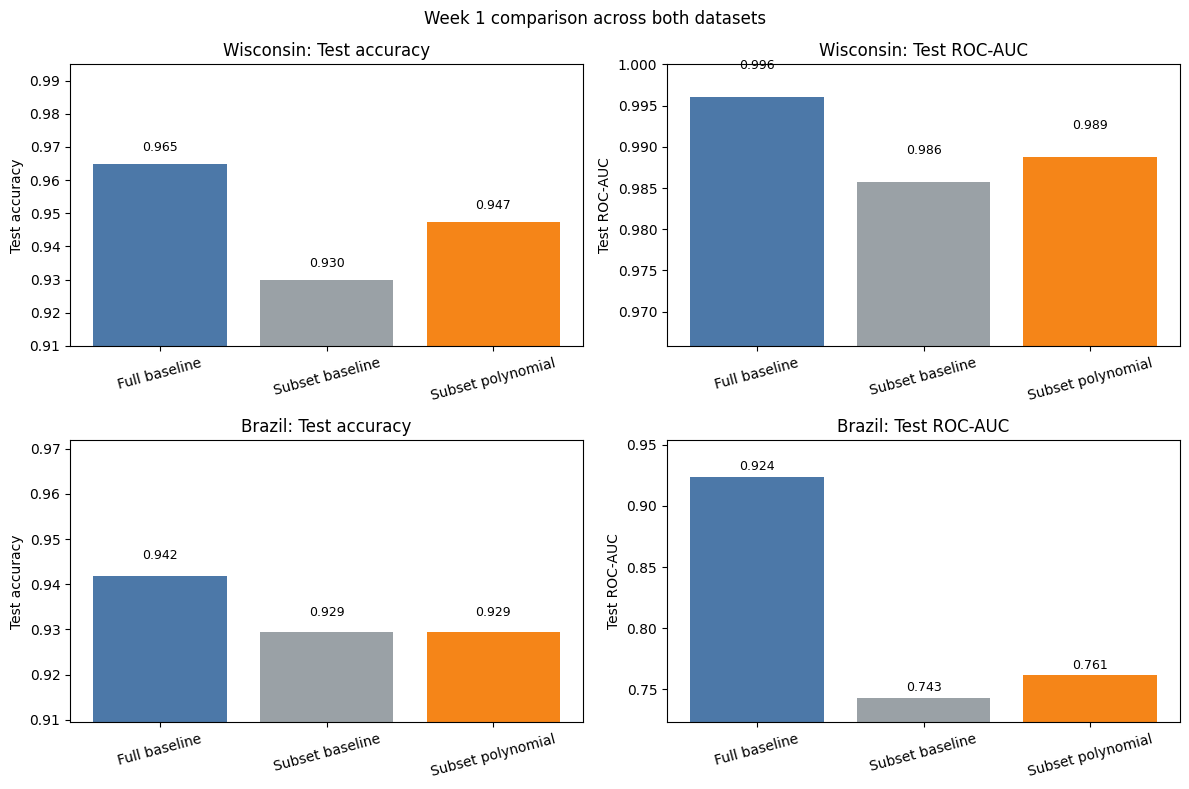

In [9]:
import matplotlib.pyplot as plt

model_labels = ['Full baseline', 'Subset baseline', 'Subset polynomial']
colors = ['#4C78A8', '#9AA1A6', '#F58518']

dataset_metrics = {
    'Wisconsin': {
        'Test accuracy': [base_test_accuracy, subset_test_accuracy, poly_test_accuracy],
        'Test ROC-AUC': [base_test_roc_auc, subset_test_roc_auc, poly_test_roc_auc],
    },
    'Brazil': {
        'Test accuracy': [brazil_base_test_accuracy, brazil_subset_test_accuracy, brazil_poly_test_accuracy],
        'Test ROC-AUC': [brazil_base_test_roc_auc, brazil_subset_test_roc_auc, brazil_poly_test_roc_auc],
    },
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row_idx, (dataset_name, metric_map) in enumerate(dataset_metrics.items()):
    for col_idx, (metric_name, values) in enumerate(metric_map.items()):
        ax = axes[row_idx, col_idx]
        bars = ax.bar(model_labels, values, color=colors)
        y_min = min(values) - 0.02
        y_max = min(1.0, max(values) + 0.03)
        ax.set_ylim(max(0, y_min), y_max)
        ax.set_title(f"{dataset_name}: {metric_name}")
        ax.set_ylabel(metric_name)
        ax.tick_params(axis="x", rotation=15)
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, value + 0.003, f"{value:.3f}", ha="center", va="bottom", fontsize=9)

fig.suptitle('Week 1 comparison across both datasets', y=0.98)
fig.tight_layout()
plt.show()


For Week 1, I compared three regression-based approaches on both cancer datasets: a full-feature baseline logistic model, a reduced five-feature baseline, and a polynomial expansion of that reduced set. On the Wisconsin dataset, the full-feature baseline performed best on the held-out test set, with accuracy of 0.9649 and ROC-AUC of 0.9960. Reducing the model to five features lowered performance, while adding polynomial and interaction terms improved that reduced model somewhat without beating the full original-feature baseline. This fits the broader Wisconsin pattern seen throughout the project: the dataset is already clean and highly separable, so extra nonlinear complexity only adds limited value.

The Brazil results told a similar but noisier story. The full-feature baseline also performed best there, with test accuracy of 0.9419 and ROC-AUC of 0.9237. Using only a five-feature subset dropped ROC-AUC substantially, and adding polynomial terms improved that reduced model from about 0.7428 to 0.7615 ROC-AUC, but still left it well below the full-feature baseline. That suggests interaction terms can recover some signal in a smaller Brazil model, but the larger and more heterogeneous dataset benefits much more from keeping the richer full feature set. Across both datasets, polynomial expansion helped the reduced model but did not justify replacing the simpler full-feature baseline.
